In [1]:
import numpy as np
import napari
import dask.array as da
from napari.utils import nbscreenshot
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

# Preprocessing the data

In [2]:
# Finger inputs
index = da.from_npy_stack(Path('..', 'data', 'Raw', 'CT Scans', 'index', 'S232028')).compute()
middle = da.from_npy_stack(Path('..', 'data', 'Raw', 'CT Scans', 'middle', 'S232028')).compute()
pinky = da.from_npy_stack(Path('..', 'data', 'Raw', 'CT Scans', 'pinky', 'S232028')).compute()
ring = da.from_npy_stack(Path('..', 'data', 'Raw', 'CT Scans', 'ring', 'S232028')).compute()

# Finger segmentations
index_label = da.from_npy_stack(Path('..', 'data', 'Raw', 'Labels', 'index', 'S232028')).compute()
middle_label = da.from_npy_stack(Path('..', 'data', 'Raw', 'Labels', 'middle', 'S232028')).compute()
pinky_label = da.from_npy_stack(Path('..', 'data', 'Raw', 'Labels', 'pinky', 'S232028')).compute()
ring_label = da.from_npy_stack(Path('..', 'data', 'Raw', 'Labels', 'ring', 'S232028')).compute()


# Check if the shapes are equal

In [3]:
# Compare shapes
print(f"Index shape: {index.shape}")
print(f"Labeled index shape: {index_label.shape}\n")

print(f"Middle shape: {middle.shape}")
print(f"Labeled Middle shape: {middle_label.shape}\n")

print(f"Pinky shape: {pinky.shape}")
print(f"Labeled Pinky shape: {pinky_label.shape}\n")

print(f"Ring shape: {ring.shape}")
print(f"Labeled Ring shape: {ring_label.shape}\n")

Index shape: (1081, 604, 523)
Labeled index shape: (604, 1081, 523)

Middle shape: (1203, 637, 561)
Labeled Middle shape: (637, 1203, 561)

Pinky shape: (993, 491, 386)
Labeled Pinky shape: (491, 993, 386)

Ring shape: (1236, 583, 530)
Labeled Ring shape: (583, 1236, 530)



In [4]:
# Transpose both 0 and 1 axes to match.
index, middle, pinky, ring = [
    arr.swapaxes(0, 1)
    for arr in (index, middle, pinky, ring)
]

In [5]:
# Confirm transpose
print("After transposing:")
print(f"Index shape: {index.shape}")
print(f"Labeled index shape: {index_label.shape}\n")

print(f"Middle shape: {middle.shape}")
print(f"Labeled Middle shape: {middle_label.shape}\n")

print(f"Pinky shape: {pinky.shape}")
print(f"Labeled Pinky shape: {pinky_label.shape}\n")

print(f"Ring shape: {ring.shape}")
print(f"Labeled Ring shape: {ring_label.shape}\n")

After transposing:
Index shape: (604, 1081, 523)
Labeled index shape: (604, 1081, 523)

Middle shape: (637, 1203, 561)
Labeled Middle shape: (637, 1203, 561)

Pinky shape: (491, 993, 386)
Labeled Pinky shape: (491, 993, 386)

Ring shape: (583, 1236, 530)
Labeled Ring shape: (583, 1236, 530)



In [6]:
index_scan = da.stack(index, axis=0)
print("CT info for finger input:")
index_scan

CT info for finger input:


dask.array<stack, shape=(604, 1081, 523), dtype=uint16, chunksize=(1, 1081, 523), chunktype=numpy.ndarray>

In [7]:
index_label_scan = da.stack(index_label, axis=0)
print("CT info for finger input:")
index_label_scan

CT info for finger input:


dask.array<stack, shape=(604, 1081, 523), dtype=int64, chunksize=(1, 1081, 523), chunktype=numpy.ndarray>

# Change data type from uint16 to float32

In [8]:
print(f"Dtype of index finger before: {index.dtype}")
index, middle, ring, pinky = [f.astype(np.float32) for f in (index, middle, ring, pinky)]
print(f"Dtype of index finger after: {index.dtype}")

Dtype of index finger before: uint16
Dtype of index finger after: float32


# Apply HU rescale

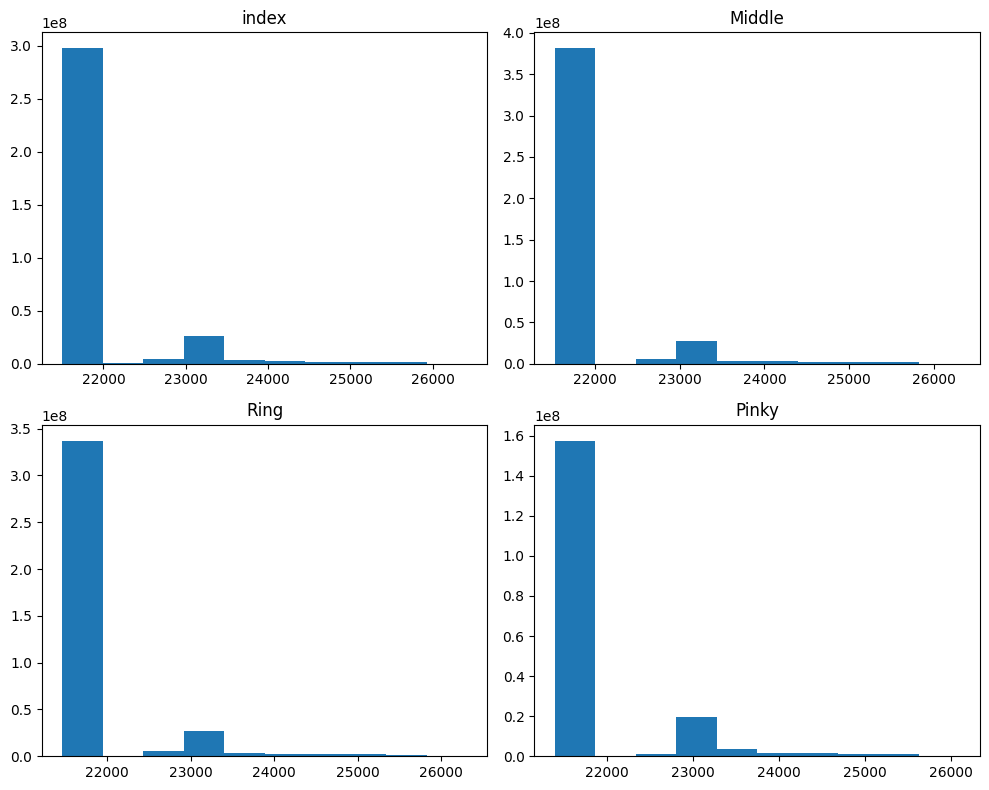

In [9]:
# Visualize our local maximas to find a range in HU scale.
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
axs = axs.flatten()
names = ["index", "Middle", "Ring", "Pinky"]

for i, finger in enumerate((index, middle, ring, pinky)):
    axs[i].hist(finger.flatten())
    axs[i].set_title(names[i])
plt.tight_layout()
plt.show()

In [10]:
print("Min:", np.min(index))
print("Max:", np.max(index))

Min: 21496.0
Max: 26418.0


In [11]:
# Identifies local maximas that will help identify
# our HU.
def peaks(CT_scan):
    # Only grab the counts and bin edges from the histogram.
    counts, bin_edges, _ = plt.hist(CT_scan.flatten(), bins=10)
    plt.close()
    # Added paddings from the beginning and the end of the values to grab the maximas
    # with no surrounding bins.
    padded_counts = np.concatenate(([0], counts))
    # Collect the indices of our peaks.
    peak_indices, _ = sp.signal.find_peaks(padded_counts, height=1)
    peak_indices = peak_indices - 1 # Moves back one index
    # Get the center of our bins
    hist_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Grab x-values of our peaks.
    peak_val = hist_centers[peak_indices]
    return peak_val

In [12]:
def HU_conversion(CT_scan):
    air, water = peaks(CT_scan)[:2] # Grabs the first two peaks, and sets them as air and water
    return ((CT_scan-water)*1000) / (water-air) # Returns formula to convert to HU.

In [13]:
"""
0th position -> air
1st position -> water
"""
index, middle, ring, pinky = [HU_conversion(f) for f in (index, middle, ring, pinky)]
print("Index finger:")
print("Max value", np.max(index))
print("Min value", np.min(index))
print("\nMiddle finger:")
print("Max value", np.max(middle))
print("Min value", np.min(middle))
print("\nRing finger:")
print("Max value", np.max(ring))
print("Min value", np.min(ring))
print("\nPinky finger:")
print("Max value", np.max(pinky))
print("Min value", np.min(pinky))

Index finger:
Max value 2166.665674628763
Min value -1166.6663359873653

Middle finger:
Max value 2166.668256013863
Min value -1166.666893716266

Ring finger:
Max value 2166.668231456569
Min value -1166.6668902080812

Pinky finger:
Max value 2166.6650560895
Min value -1166.6664365842144


# Clip HU values in range from -1000 and 3000+

In [14]:
# Before clipping
print("Before clipping:")
print("Max index:", np.max(index))
print("Max middle:", np.max(middle))
print("Max ring:", np.max(ring))
print("Max pinky:", np.max(pinky))

print("Min index:", np.min(index))
print("Min middle:", np.min(middle))
print("Min ring:", np.min(ring))
print("Min pinky:", np.min(pinky))

Before clipping:
Max index: 2166.665674628763
Max middle: 2166.668256013863
Max ring: 2166.668231456569
Max pinky: 2166.6650560895
Min index: -1166.6663359873653
Min middle: -1166.666893716266
Min ring: -1166.6668902080812
Min pinky: -1166.6664365842144


In [15]:
index, middle, ring, pinky = [np.clip(f, -1000, 3000) for f in (index, middle, ring, pinky)]

In [16]:
# After clipping 
print("After clipping:")
print("Max index:", np.max(index))
print("Max middle:", np.max(middle))
print("Max ring:", np.max(ring))
print("Max pinky:", np.max(pinky))

print("Min index:", np.min(index))
print("Min middle:", np.min(middle))
print("Min ring:", np.min(ring))
print("Min pinky:", np.min(pinky))

After clipping:
Max index: 2166.665674628763
Max middle: 2166.668256013863
Max ring: 2166.668231456569
Max pinky: 2166.6650560895
Min index: -1000.0
Min middle: -1000.0
Min ring: -1000.0
Min pinky: -1000.0


# Normalization using z-score to scale values 
$Z = \frac{X-\mu}{\sigma}$

In [17]:
def zScore(CT_scan):
    mean = np.mean(CT_scan)
    std = np.std(CT_scan)
    return (CT_scan-mean) / (std + 1e-8)

In [18]:
index, middle, ring, pinky = [zScore(f) for f in (index, middle, ring, pinky)]

In [19]:
# The average is close to 0 with a standard deviation of 1.
print("Index max value", np.max(index))
print("Index min value", np.min(index))
print("\nMean of the index:", np.mean(index))
print("STD of the index:", np.std(index))

Index max value 7.0621124667986885
Index min value -0.34988865785017725

Mean of the index: -1.3603048119606589e-14
STD of the index: 0.9999999999764361


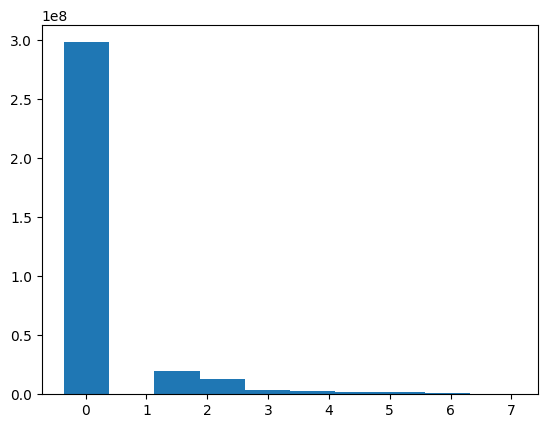

In [20]:
# Display the new scaled values in a histogram
plt.hist(index.flatten())
plt.show()

# Add padding to match both inputs and outputs spatial size

In [21]:
# Maximum shape for each CT scan: (637, 1236, 561)
def padding(CT_scan, max_shape=(637, 1236, 561)):
    d, h, w = CT_scan.shape # depth, height, width
    md, mh, mw = max_shape # max_depth, max_height, max_width
    pad = [
        ((md-d)//2, (md-d) - (md-d)//2), # Depth
        ((mh-h)//2, (mh-h) - (mh-h)//2), # Height
        ((mw-w)//2, (mw-w) - (mw-w)//2), # Width
    ]
    res = np.pad(CT_scan, pad, mode='constant', constant_values=0)
    return res

In [22]:
# Add padding to each finger input:
index, middle, ring, pinky = [padding(f) for f in (index, middle, ring, pinky)]
# Add padding to each finger ouput:
index_label, middle_label, ring_label, pinky_label = [padding(f) for f in (index_label, middle_label, ring_label, pinky_label)]

In [23]:
# Confirm shapes
# Shapes must be (637, 1236, 561)
print("Input shapes:")
print(f"Index shape: {index.shape}")
print(f"Middle shape: {middle.shape}")
print(f"Ring shape: {ring.shape}")
print(f"Pinky shape: {pinky.shape}")

print("\nLabel shapes:")
print(f"Index shape: {index_label.shape}")
print(f"Middle shape: {middle_label.shape}")
print(f"Ring shape: {ring_label.shape}")
print(f"Pinky shape: {pinky_label.shape}")

Input shapes:
Index shape: (637, 1236, 561)
Middle shape: (637, 1236, 561)
Ring shape: (637, 1236, 561)
Pinky shape: (637, 1236, 561)

Label shapes:
Index shape: (637, 1236, 561)
Middle shape: (637, 1236, 561)
Ring shape: (637, 1236, 561)
Pinky shape: (637, 1236, 561)


In [24]:
print(np.min(index))
print(np.max(index))

-0.34988865785017725
7.0621124667986885


# Add files to path location

# Add preprocessed inputs to path location

In [25]:
# Loop through every 2D array (slice) and append each to the folder as an .npy file.
fingers = ['index', 'middle', 'ring', 'pinky']
scans = [index, middle, ring, pinky]

base_path = Path('../data/Preprocessed/CT Scans/')

for name, scan in zip(fingers, scans):
    # Add folders for each finger
    finger_folder = base_path / name / "S232028"
    finger_folder.mkdir(parents=True, exist_ok=True)

    # Loops through each slice in a volume
    for i in range(scan.shape[0]):
        slice_2d = scan[i]

        file_path = finger_folder / f"{i}.npy"
        np.save(file_path, slice_2d)

# Add preprocessed segmentations to path location

In [26]:
# Loop through every 2D array (slice) and append each to the folder as an .npy file.
fingers = ['index', 'middle', 'ring', 'pinky']
labels = [index_label, middle_label, ring_label, pinky_label]

base_path = Path('../data/Preprocessed/Labels/')

for name, label in zip(fingers, labels):
    # Add folders for each finger
    finger_folder = base_path / name / "S232028"
    finger_folder.mkdir(parents=True, exist_ok=True)

    # Loops through each slice in a volume
    for i in range(label.shape[0]):
        slice_2d = label[i]

        file_path = finger_folder / f"{i}.npy"
        np.save(file_path, slice_2d)